# Model

The `Model` class connects a simulator to its `JointPrior`. It draws parameter values, broadcasts time-invariant values across steps, calls the simulator in batches, and returns observations and parameters in one named dictionary. It can also apply optional contamination and missingness processes.

## Example

We continue with the DDM example. The prior lets drift rate, boundary separation, and non-decision time vary independently across observations, while starting bias stays fixed.

In [ ]:
import superstats as sup

In [2]:
simulator = sup.simulation.sample_ddm

In [3]:
prior = sup.JointPrior(
    v=sup.transition.RandomWalk(bounds=(0.0, 6.0)),
    a=sup.transition.RandomWalk(bounds=(0.2, 4.0)),
    tau=sup.transition.RandomWalk(bounds=(0.0, 2.0)),
    bias=0.5,
)

In [7]:
model = sup.Model(
    simulator=simulator,
    prior=prior,
    missing=None,
    contamination=None,
)

This example disables both augmentation processes. This is explicit because `Model` otherwise defaults to `missing="random"`. We now draw 100 independent parameter configurations and simulate a 200-observation sequence from each.

In [8]:
sim_data = model.sample(
    batch_size=100,
    num_steps=200,
)

print(sim_data.keys())

dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'tau', 'v_sigma', 'a_sigma', 'tau_sigma'])


Every observation and parameter has its own dictionary key. Here, `response_time`, `choice`, and `time_steps` have shape `(100, 200)`. The local parameters `v`, `a`, and `tau` have shape `(100, 200, 1)`, while their transition scales have shape `(100, 1)`. The fixed `bias` is used by the simulator but is not returned as an inference target.

## Prior Push-forward Checks

Before training, check whether the combined prior and simulator generate credible observations. A prior push-forward check can reveal impossible values, excessive variability, unrealistic tails, or temporal patterns that do not match domain knowledge. Revise the model assumptions when it fails; more neural-network training cannot repair an implausible generative model.

Simulate five datasets (`batch_size=5`) each with 200 observations (`num_steps=200`) and plot per dataset (`aggregation=None`) response time (`data_dim=0`) distributions (`kind="dist"`).

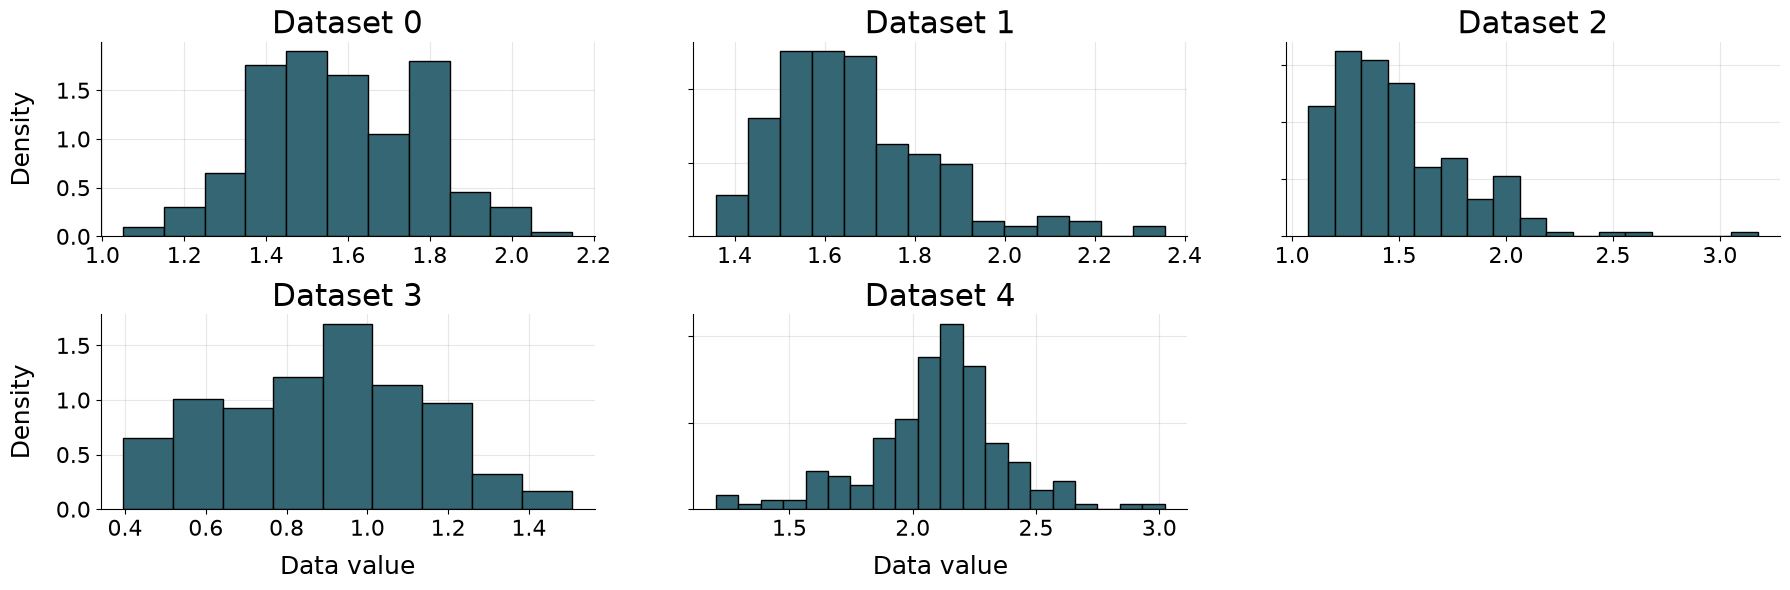

In [17]:
fig = model.plot_push_forward(
    batch_size=5,
    num_steps=200,
    data_dim="response_time",
    kind="dist",
    dist_type="hist",
    aggregation=None,
)

Alternatively, we can plot choices (`data_dim=1`) as time series (`kind="time_series"`) aggregated across datasets by median (`aggregation=np.median`). Additionally, we depict variation as standard deviation (`uncertainty_fun="std"`), show individual datasets (`spaggetti=True`), and display the marginal distribution (`marginal=True`) as a kernel density (`dist_type="kde"`).

Disclaimer: we could choose better settings for plotting push forward checks for choices. Here, I simply wanted to demonstrate the flexible possibilities of the `plot_push_forward()` method.

In [18]:
import numpy as np

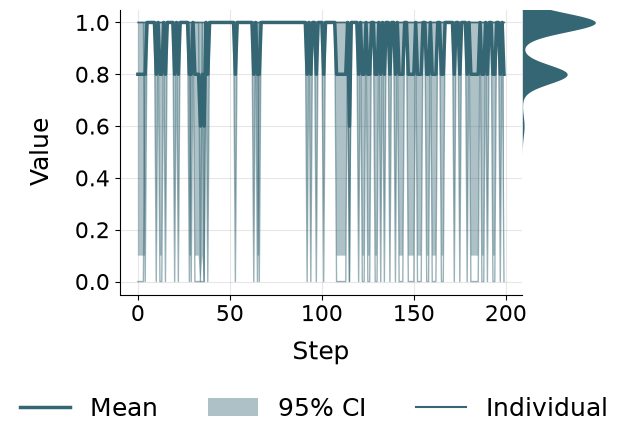

In [21]:
fig = model.plot_push_forward(
    batch_size=5,
    num_steps=200,
    data_dim="choice",
    kind="time_series",
    aggregation=np.mean,
    uncertainty_fun="95ci",
    spaghetti=True,
    marginal=True,
    dist_type="kde",
)